## Evaluate sensitivity overall

In [1]:
import os, re, glob
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt

# Root where your experiments live
ROOT = "/data/shared/fsibilla/clean_code/Q1/experiments"

# If you want to restrict to a subset, list them here; otherwise it auto-discovers.
DATASETS_WHITELIST =  ["zwe_mics", "lka_micron", "yem_mvam", 'lka_vam','moz_vam','nga_mics','nga_micron','eth_micron']

# Expected up to 4 train-percent files per dataset (some missing, as you said)
MAX_POS = 4

# Variability band: "se" (default), "sd", or "ci95"
BAND = "se"

In [2]:
import os, glob, re
import pandas as pd

FILE_RE = re.compile(r"eval_adm1_seed_metrics_train_(\d+)\.csv$")

def discover_files(root=ROOT, whitelist=DATASETS_WHITELIST):
    pattern = os.path.join(root, "*", "results", "evaluation", "eval_adm1_seed_metrics_train_*.csv")
    files = glob.glob(pattern)
    rows = []
    for fp in files:
        m = FILE_RE.search(fp)
        if not m:
            continue
        tp_str = m.group(1)          # e.g. "01" or "1"
        tp_int = int(tp_str)         # both -> 1
        tp_len = len(tp_str)         # "01" -> 2, "1" -> 1

        dataset = os.path.basename(os.path.dirname(os.path.dirname(os.path.dirname(fp))))
        if whitelist is not None and dataset not in whitelist:
            continue

        rows.append((dataset, tp_int, tp_len, tp_str, fp))

    out = (pd.DataFrame(rows, columns=["dataset", "train_percent", "tp_len", "tp_str", "path"])
             .sort_values(["dataset", "train_percent", "tp_len", "tp_str"],
                          ascending=[True, True, False, True],
                          kind="mergesort")  # stable
          )
    return out

files_df = discover_files()
files_df

,dataset,train_percent,tp_len,tp_str,path
20,eth_micron,1,1,1,/data/shared/fsibilla/clean_code/Q1/experiment...
22,eth_micron,2,1,2,/data/shared/fsibilla/clean_code/Q1/experiment...
23,eth_micron,4,1,4,/data/shared/fsibilla/clean_code/Q1/experiment...
21,eth_micron,8,1,8,/data/shared/fsibilla/clean_code/Q1/experiment...
16,lka_micron,1,1,1,/data/shared/fsibilla/clean_code/Q1/experiment...
18,lka_micron,2,1,2,/data/shared/fsibilla/clean_code/Q1/experiment...
19,lka_micron,4,1,4,/data/shared/fsibilla/clean_code/Q1/experiment...
17,lka_micron,8,1,8,/data/shared/fsibilla/clean_code/Q1/experiment...
28,lka_vam,1,1,1,/data/shared/fsibilla/clean_code/Q1/experiment...
30,lka_vam,2,1,2,/data/shared/fsibilla/clean_code/Q1/experiment...


In [3]:
def add_position_rank(files_df: pd.DataFrame) -> pd.DataFrame:
    df = files_df.copy()
    df["pos"] = (
        df.sort_values(["dataset","train_percent"])
          .groupby("dataset")
          .cumcount() + 1
    )
    return df

files_df = add_position_rank(files_df)

# Quick sanity check: which datasets have which positions?
pivot = (files_df.groupby("dataset")["pos"]
         .apply(lambda s: sorted(s.tolist()))
         .rename("positions_available")
         .reset_index())
pivot

,dataset,positions_available
0,eth_micron,"[1, 2, 3, 4]"
1,lka_micron,"[1, 2, 3, 4]"
2,lka_vam,"[1, 2, 3, 4]"
3,moz_vam,"[1, 2, 3, 4]"
4,nga_micron,"[1, 2, 3, 4]"
5,nga_mics,"[1, 2, 3, 4]"
6,yem_mvam,"[1, 2, 3, 4]"
7,zwe_mics,"[1, 2, 3, 4]"


In [4]:
def load_and_compute_improvements(files_df: pd.DataFrame) -> pd.DataFrame:
    frames = []
    for _, r in files_df.iterrows():
        df = pd.read_csv(r["path"])
        df["dataset"] = r["dataset"]
        df["train_percent"] = r["train_percent"]
        df["pos"] = r["pos"]

        # improvements (baseline - gen): positive => GEN better (assuming lower is better)
        df["imp_emd_nat"]  = df["emd_nat"]  - df["emd_gen"]
        df["imp_emd_over"] = df["emd_over"] - df["emd_gen"]
        df["imp_absmeanerr_nat"]  = df["absmeanerr_nat"]  - df["absmeanerr_gen"]
        df["imp_absmeanerr_over"] = df["absmeanerr_over"] - df["absmeanerr_gen"]

        frames.append(df)

    all_df = pd.concat(frames, ignore_index=True)
    return all_df

all_df = load_and_compute_improvements(files_df)

all_df[["dataset","pos","train_percent","seed","adm1_code","target",
        "imp_emd_nat","imp_emd_over","imp_absmeanerr_nat","imp_absmeanerr_over"]].head()

,dataset,pos,train_percent,seed,adm1_code,target,imp_emd_nat,imp_emd_over,imp_absmeanerr_nat,imp_absmeanerr_over
0,eth_micron,1,1,1,Addis Ababa,va_ai,-0.130903,0.304462,-0.138716,0.832841
1,eth_micron,1,1,1,Addis Ababa,fol_ai,0.039488,0.052142,0.184102,0.168988
2,eth_micron,1,1,1,Addis Ababa,vb12_ai,-0.674689,0.174757,-3.185863,0.725270
3,eth_micron,1,1,1,Addis Ababa,fe_ai,0.128043,0.175980,0.619319,0.248997
4,eth_micron,1,1,1,Addis Ababa,zn_ai,0.142539,0.140868,0.834056,0.210835


In [5]:
IMP_COLS = [
    "imp_emd_nat",
    "imp_emd_over",
    "imp_absmeanerr_nat",
    "imp_absmeanerr_over",
]

def summarize_by_pos(all_df: pd.DataFrame, band=BAND) -> pd.DataFrame:
    g = all_df.groupby("pos", as_index=False)

    summary = g[IMP_COLS].mean().rename(columns={c: c.replace("imp_", "") + "_mean" for c in IMP_COLS})

    # variability
    n = g.size().rename(columns={"size":"n"})
    sd = g[IMP_COLS].std(ddof=1).rename(columns={c: c.replace("imp_", "") + "_sd" for c in IMP_COLS})

    out = summary.merge(n, on="pos").merge(sd, on="pos")
    for c in IMP_COLS:
        base = c.replace("imp_", "")
        out[f"{base}_se"] = out[f"{base}_sd"] / np.sqrt(out["n"])

    if band == "sd":
        out["band_kind"] = "sd"
    elif band == "ci95":
        out["band_kind"] = "ci95"
        # normal approx; if you want t-based CI, say so.
        for base in [c.replace("imp_","") for c in IMP_COLS]:
            out[f"{base}_band"] = 1.96 * out[f"{base}_se"]
    else:
        out["band_kind"] = "se"

    return out.sort_values("pos")

sum_df = summarize_by_pos(all_df, band=BAND)
sum_df

,pos,emd_nat_mean,emd_over_mean,absmeanerr_nat_mean,absmeanerr_over_mean,n,emd_nat_sd,emd_over_sd,absmeanerr_nat_sd,absmeanerr_over_sd,emd_nat_se,emd_over_se,absmeanerr_nat_se,absmeanerr_over_se,band_kind
0,1,0.007863,0.160158,0.037881,0.523980,3575,0.212415,0.350735,0.836869,1.641019,0.003553,0.005866,0.013996,0.027446,se
1,2,0.025502,0.092212,0.100157,0.306996,3575,0.185683,0.240728,0.748092,1.204345,0.003106,0.004026,0.012512,0.020142,se
2,3,0.041025,0.021400,0.124677,0.033438,3575,0.170056,0.183837,0.747300,0.962475,0.002844,0.003075,0.012498,0.016097,se
3,4,0.050352,-0.038552,0.133606,-0.189704,3575,0.168709,0.156451,1.017273,0.982915,0.002822,0.002617,0.017014,0.016439,se


In [ ]:
# WHAT THIS CELL DOES (in plain English):
#
# The paper says: "improvement over oversampling declines monotonically with
# training sample size in all cases" (around Figure 3A). That sentence is
# currently a description of what the plots LOOK LIKE; it is not backed by a
# statistical test. A SA reviewer will ask "how do you know this isn't noise?"
#
# This cell fits a model that asks: ACROSS all datasets, all target variables,
# all regions, and all seeds taken together, is the relationship between
# improvement and log(sample size) reliably negative?
#
# The model:
#   improvement_i  =  alpha + beta * log(pos_i) + u_{dataset:target} + epsilon_i
# where:
#   - improvement_i is the per-(seed, adm1, target, pos) improvement value
#   - pos_i is the PSU-level (1, 2, 4, 8 -- on a comparable scale across countries)
#   - u_{dataset:target} is a random intercept per (dataset, target) cluster:
#     accounts for the fact that some (dataset, target) pairs sit at higher
#     baseline improvement than others
#   - epsilon_i is residual variance: variation across seeds and ADM1s within
#     a (dataset, target) cluster
#
# OUTPUT to look at:
#   - the slope on log_pos (call it beta)
#     - beta < 0  AND  p < 0.05  =>  monotone decline IS statistically supported
#     - beta > 0  AND  p < 0.05  =>  the claim is contradicted
#     - p >= 0.05                =>  the data dont reliably support the claim
#   - per-dataset slopes printed below the mixed-effects result are a sanity
#     check: how many of the 8 datasets individually show a negative slope?
#
# Why this model and not a per-dataset t-test for each: with 8 datasets and
# multiple targets per dataset, doing 8+ separate tests inflates the false
# positive rate and discards the cross-dataset structure. The mixed-effects
# model pools across all datasets while respecting that observations within
# a (dataset, target) cluster arent independent.

import numpy as np
import pandas as pd

try:
    import statsmodels.formula.api as smf
    HAS_SM = True
except ImportError:
    HAS_SM = False
    print("statsmodels not available; falling back to per-dataset OLS only.")


def run_decline_test_mixedlm(all_df, outcome="imp_emd_over"):
    df = all_df[["dataset", "adm1_code", "target", "pos", "seed", outcome]].dropna().copy()
    df["log_pos"] = np.log(df["pos"].astype(float))
    df["dataset_target"] = df["dataset"].astype(str) + "::" + df["target"].astype(str)
    # Random intercept per (dataset, target). Variation across seeds and ADM1s
    # within a (dataset, target) cluster goes to residual variance -- simplest
    # spec that respects the clustering. We previously also added
    # vc_formula={"adm1": "0 + C(adm1_code)"} but adm1_code values are not
    # nested cleanly within (dataset, target) clusters across the dataset, which
    # made the variance components estimate weakly identifiable.
    md = smf.mixedlm(
        f"{outcome} ~ log_pos",
        data=df,
        groups=df["dataset_target"],
        re_formula="~1",
    )
    return md.fit(method="lbfgs", reml=True)


def per_dataset_slopes(all_df, outcome="imp_emd_over"):
    """Per-dataset linear fit of seed-averaged improvement on log(pos)."""
    rows = []
    for ds, sub in all_df.dropna(subset=[outcome]).groupby("dataset"):
        by_pos = sub.groupby("pos")[outcome].mean()
        if len(by_pos) < 2:
            continue
        log_pos = np.log(by_pos.index.values.astype(float))
        y = by_pos.values
        m, b = np.polyfit(log_pos, y, 1)
        rows.append({"dataset": ds, "slope_log_pos": m, "intercept": b, "n_pos": len(by_pos)})
    return pd.DataFrame(rows)


METRICS = ["imp_emd_over", "imp_emd_nat", "imp_absmeanerr_over", "imp_absmeanerr_nat"]

mixedlm_results = {}
for outcome in METRICS:
    print("")
    print(f"========== {outcome} ==========")
    if HAS_SM:
        try:
            res = run_decline_test_mixedlm(all_df, outcome=outcome)
            slope = res.fe_params["log_pos"]
            se    = res.bse["log_pos"]
            z     = res.tvalues["log_pos"]
            p     = res.pvalues["log_pos"]
            ci_lo, ci_hi = slope - 1.96 * se, slope + 1.96 * se
            tag = ""
            if p < 0.001:
                tag = " ***"
            elif p < 0.01:
                tag = " **"
            elif p < 0.05:
                tag = " *"
            print(f"  Mixed-effects slope on log(pos):"
                  f" {slope:+.4f}  (95% CI [{ci_lo:+.4f}, {ci_hi:+.4f}])"
                  f"  z={z:+.2f}  p={p:.3g}{tag}")
            if slope < 0 and p < 0.05:
                print("    → SIGNIFICANT MONOTONE DECLINE")
            elif slope > 0 and p < 0.05:
                print("    → SIGNIFICANT INCREASE  (claim contradicted)")
            else:
                print("    → no significant slope")
            mixedlm_results[outcome] = res
        except Exception as e:
            print(f"  mixedlm failed: {e}")
            mixedlm_results[outcome] = None

    # per-dataset sanity check
    pds = per_dataset_slopes(all_df, outcome=outcome)
    n_neg = int((pds["slope_log_pos"] < 0).sum())
    n_total = len(pds)
    print(f"  Per-dataset slopes (sign of log_pos coefficient):"
          f" {n_neg}/{n_total} datasets have negative slope")
    print(pds.round(4).to_string(index=False))


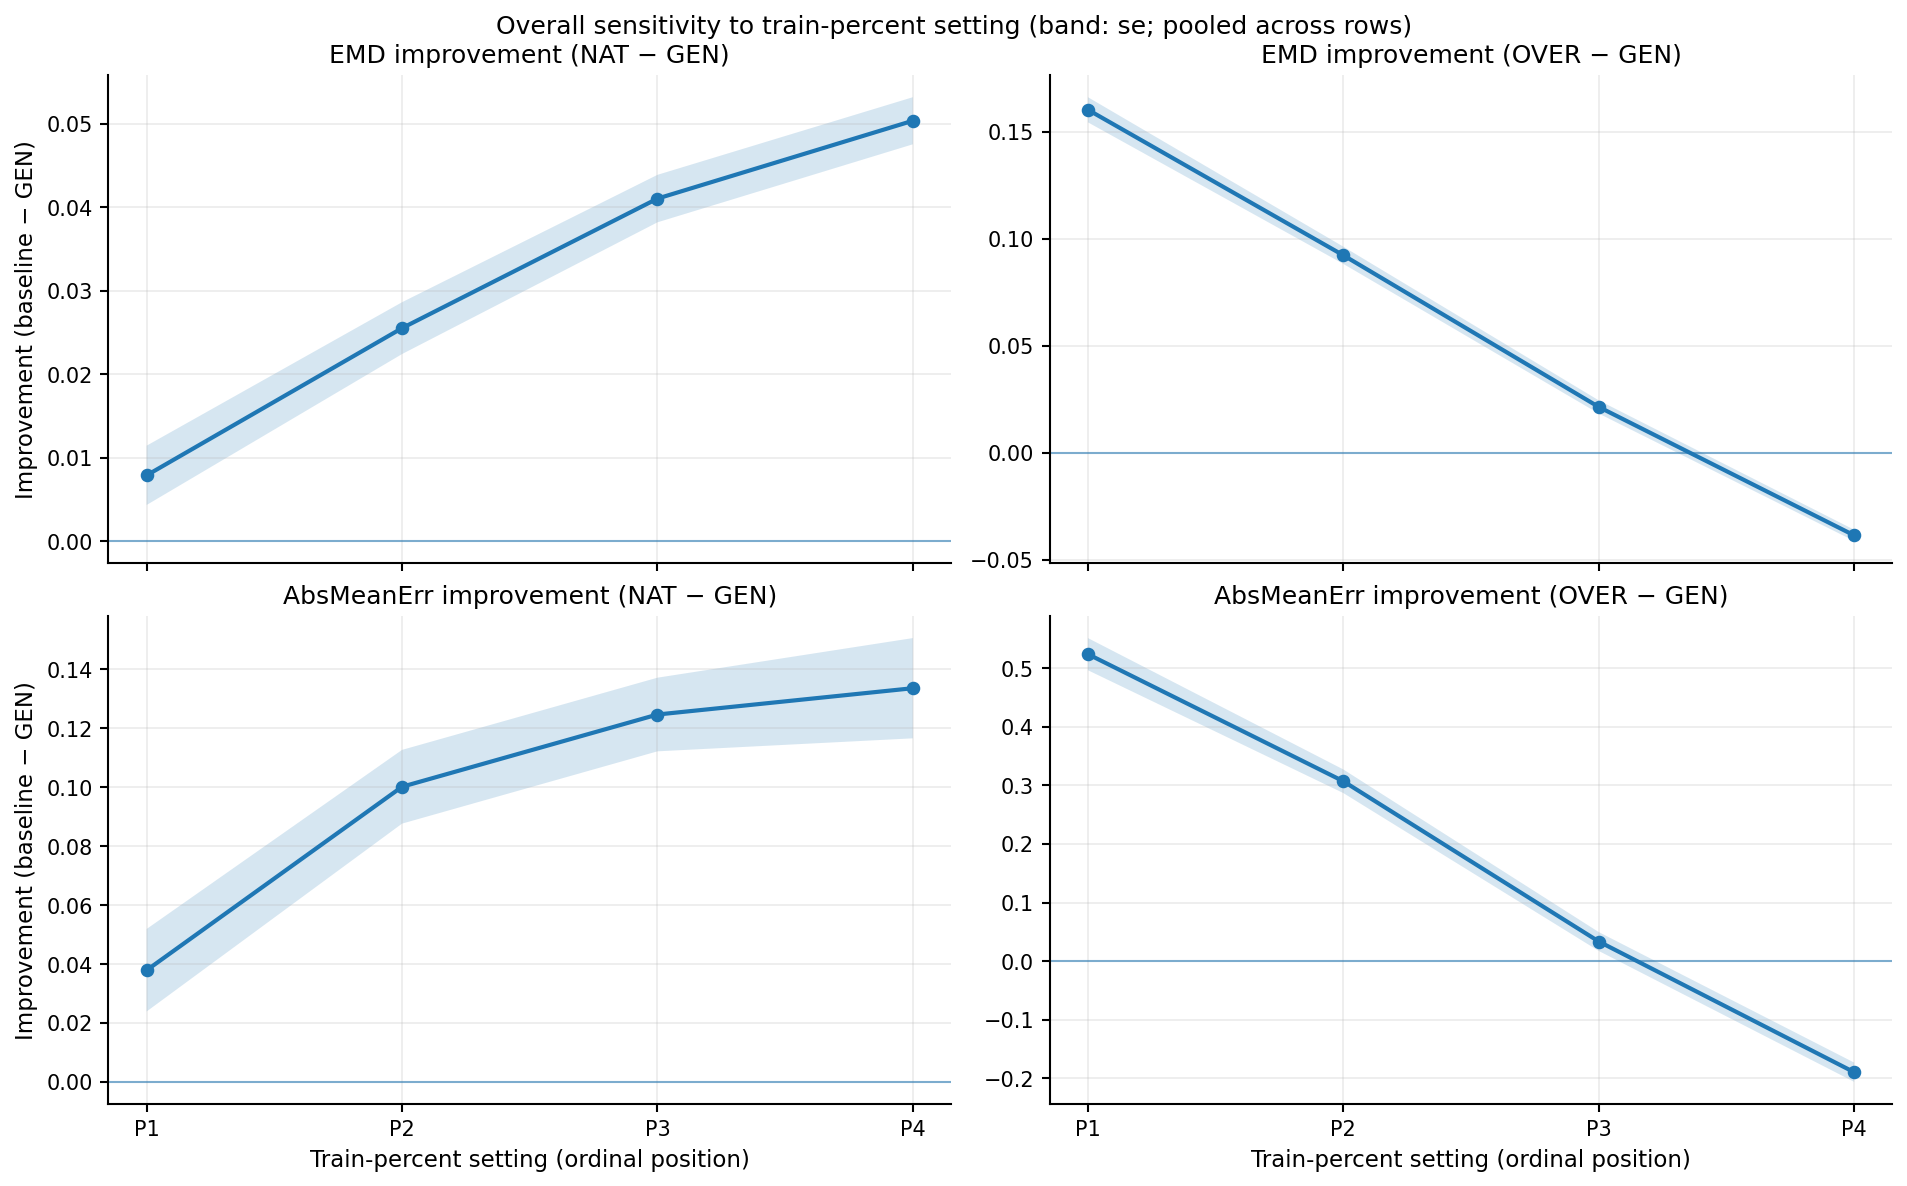

In [6]:
# --- paper-ish styling
mpl.rcParams.update({
    "figure.dpi": 150,
    "savefig.dpi": 300,
    "font.size": 11,
    "axes.titlesize": 12,
    "axes.labelsize": 11,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "legend.fontsize": 10,
    "axes.linewidth": 1.0,
    "lines.linewidth": 2.0,
    "lines.markersize": 5.5,
    "grid.linewidth": 0.8,
    "grid.alpha": 0.25,
})

def despine(ax):
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

def get_band(sum_df, base, band_kind):
    if band_kind == "sd":
        return sum_df[f"{base}_sd"].to_numpy()
    if band_kind == "ci95":
        return sum_df[f"{base}_band"].to_numpy()
    return sum_df[f"{base}_se"].to_numpy()  # default SE

x = np.arange(1, MAX_POS + 1)

# Reindex to ensure missing positions show up as gaps
plot_df = (sum_df.set_index("pos")
                 .reindex(x)
                 .reset_index()
                 .rename(columns={"index":"pos"}))

fig, axes = plt.subplots(2, 2, figsize=(12.6, 7.6), constrained_layout=True, sharex=True)

panels = [
    ("emd_nat", "EMD improvement (NAT − GEN)"),
    ("emd_over", "EMD improvement (OVER − GEN)"),
    ("absmeanerr_nat", "AbsMeanErr improvement (NAT − GEN)"),
    ("absmeanerr_over", "AbsMeanErr improvement (OVER − GEN)"),
]

for ax, (base, title) in zip(axes.ravel(), panels):
    y = plot_df[f"{base}_mean"].to_numpy()
    b = get_band(plot_df, base, plot_df["band_kind"].dropna().iloc[0] if plot_df["band_kind"].notna().any() else "se")

    ax.plot(x, y, marker="o")
    ax.fill_between(x, y - b, y + b, alpha=0.18, linewidth=0)

    ax.axhline(0, linewidth=1.0, alpha=0.55)
    ax.set_title(title)
    ax.grid(True)
    ax.tick_params(direction="out", length=4, width=1)
    despine(ax)

for ax in axes[1, :]:
    ax.set_xlabel("Train-percent setting (ordinal position)")
for ax in axes[:, 0]:
    ax.set_ylabel("Improvement (baseline − GEN)")

# optional: nicer x ticks
for ax in axes.ravel():
    ax.set_xticks(x)
    ax.set_xticklabels([f"P{i}" for i in x])

fig.suptitle(f"Overall sensitivity to train-percent setting (band: {BAND}; pooled across rows)", y=1.02, fontsize=12)
plt.show()

# Optional save
# fig.savefig("sensitivity_train_percent_ordinal.pdf", bbox_inches="tight")
# fig.savefig("sensitivity_train_percent_ordinal.png", bbox_inches="tight")

In [7]:
import numpy as np
import pandas as pd

MAX_POS = 4
BAND = "sd"  # "se", "sd", or "ci95"

def _clean_np(a):
    a = np.asarray(a, dtype=float)
    return a[np.isfinite(a)]

def _sd(a):
    a = _clean_np(a)
    if a.size <= 1:
        return np.nan
    return a.std(ddof=1)

def _se(a):
    a = _clean_np(a)
    if a.size <= 1:
        return np.nan
    return a.std(ddof=1) / np.sqrt(a.size)

# Row-level improvements for OVER baseline (baseline - gen)
all_df["imp_emd_over"] = all_df["emd_over"] - all_df["emd_gen"]
all_df["imp_absmeanerr_over"] = all_df["absmeanerr_over"] - all_df["absmeanerr_gen"]

def summarize_over(all_df: pd.DataFrame, band=BAND) -> pd.DataFrame:
    out_rows = []
    for pos, d in all_df.groupby("pos"):
        # components
        emd_g = d["emd_gen"].to_numpy()
        emd_b = d["emd_over"].to_numpy()
        ame_g = d["absmeanerr_gen"].to_numpy()
        ame_b = d["absmeanerr_over"].to_numpy()

        # improvements as row-level diffs (recommended)
        emd_imp = d["imp_emd_over"].to_numpy()
        ame_imp = d["imp_absmeanerr_over"].to_numpy()

        row = {
            "pos": pos,
            "n_emd_imp": int(np.isfinite(emd_imp).sum()),
            "n_ame_imp": int(np.isfinite(ame_imp).sum()),

            "emd_gen_mean": np.nanmean(emd_g),
            "emd_over_mean": np.nanmean(emd_b),
            "emd_imp_mean": np.nanmean(emd_imp),

            "absmeanerr_gen_mean": np.nanmean(ame_g),
            "absmeanerr_over_mean": np.nanmean(ame_b),
            "absmeanerr_imp_mean": np.nanmean(ame_imp),

            # component variability
            "emd_gen_sd": _sd(emd_g),
            "emd_over_sd": _sd(emd_b),
            "absmeanerr_gen_sd": _sd(ame_g),
            "absmeanerr_over_sd": _sd(ame_b),

            "emd_gen_se": _se(emd_g),
            "emd_over_se": _se(emd_b),
            "absmeanerr_gen_se": _se(ame_g),
            "absmeanerr_over_se": _se(ame_b),

            # improvement variability via row-level diffs (accounts for correlation)
            "emd_imp_sd": _sd(emd_imp),
            "emd_imp_se": _se(emd_imp),
            "absmeanerr_imp_sd": _sd(ame_imp),
            "absmeanerr_imp_se": _se(ame_imp),
        }
        out_rows.append(row)

    sum_over = pd.DataFrame(out_rows).sort_values("pos")

    # Reindex to preserve gaps for missing ordinal positions
    x = np.arange(1, MAX_POS + 1)
    sum_over = (sum_over.set_index("pos")
                        .reindex(x)
                        .reset_index()
                        .rename(columns={"index": "pos"}))

    # Optional: “propagated” SE assuming independence between baseline & gen means
    sum_over["emd_imp_se_prop_indep"] = np.sqrt(sum_over["emd_over_se"]**2 + sum_over["emd_gen_se"]**2)
    sum_over["absmeanerr_imp_se_prop_indep"] = np.sqrt(sum_over["absmeanerr_over_se"]**2 + sum_over["absmeanerr_gen_se"]**2)

    sum_over["band_kind"] = band
    return sum_over

sum_over = summarize_over(all_df, band=BAND)
sum_over

,pos,n_emd_imp,n_ame_imp,emd_gen_mean,emd_over_mean,emd_imp_mean,absmeanerr_gen_mean,absmeanerr_over_mean,absmeanerr_imp_mean,emd_gen_sd,...,emd_over_se,absmeanerr_gen_se,absmeanerr_over_se,emd_imp_sd,emd_imp_se,absmeanerr_imp_sd,absmeanerr_imp_se,emd_imp_se_prop_indep,absmeanerr_imp_se_prop_indep,band_kind
0,1,3575,3575,0.285344,0.445502,0.160158,0.895655,1.419634,0.523980,0.220491,...,0.006372,0.014344,0.028528,0.350735,0.005866,1.641019,0.027446,0.007362,0.031931,sd
1,2,3575,3575,0.236763,0.328975,0.092212,0.765760,1.072756,0.306996,0.173346,...,0.004039,0.011804,0.020258,0.240728,0.004026,1.204345,0.020142,0.004972,0.023446,sd
2,3,3575,3575,0.208768,0.230168,0.021400,0.724627,0.758065,0.033438,0.139502,...,0.002660,0.012223,0.014536,0.183837,0.003075,0.962475,0.016097,0.003539,0.018992,sd
3,4,3575,3575,0.193909,0.155357,-0.038552,0.697181,0.507477,-0.189704,0.142481,...,0.001642,0.016381,0.009226,0.156451,0.002617,0.982915,0.016439,0.002894,0.018801,sd


In [8]:
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np

# Paper-ish styling (no explicit colors)
mpl.rcParams.update({
    "figure.dpi": 150,
    "savefig.dpi": 300,
    "font.size": 11,
    "axes.titlesize": 12,
    "axes.labelsize": 11,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "legend.fontsize": 10,
    "axes.linewidth": 1.0,
    "lines.linewidth": 2.0,
    "lines.markersize": 5.5,
    "grid.linewidth": 0.8,
    "grid.alpha": 0.25,
})

def despine(ax):
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

def get_band(sum_df, col_base, kind):
    """
    col_base like "emd_gen" / "emd_over" / "emd_imp"
    kind: "se", "sd", "ci95"
    """
    if kind == "sd":
        return sum_df[f"{col_base}_sd"].to_numpy()
    se = sum_df[f"{col_base}_se"].to_numpy()
    if kind == "ci95":
        return 1.96 * se
    return se  # default SE

def plot_over_metric(
    sum_over,
    metric="emd",
    band_kind="se",
    impr_band="rowdiff",
    x_vals=(1, 2, 4, 8),
    x_label="PSU per ADM1",
):
    """
    Plot OVER baseline for one metric in a 1×2 layout:
      - left: improvement (OVER - GEN)
      - right: components (GEN error, OVER baseline error)

    Parameters
    ----------
    sum_over : pd.DataFrame
        Output of summarize_over(...), reindexed to 4 positions with possible NaNs.
    metric : {"emd", "absmeanerr"}
    band_kind : {"se", "sd", "ci95"}
        What the shaded band represents.
    impr_band : {"rowdiff", "prop_indep"}
        - "rowdiff": uses metric_imp_{se/sd} computed from row-level diffs (recommended)
        - "prop_indep": uses metric_imp_se_prop_indep (assumes independence of means)
    x_vals : tuple/list/np.ndarray
        Actual x coordinates to plot at (default 1,2,4,8).
    x_label : str
    """
    x = np.asarray(x_vals, dtype=float)

    fig, (ax0, ax1) = plt.subplots(
        1, 2, figsize=(12.6, 4.2), constrained_layout=True, sharex=True
    )

    # ----- Improvement
    y = sum_over[f"{metric}_imp_mean"].to_numpy()

    if impr_band == "prop_indep":
        se_imp = sum_over[f"{metric}_imp_se_prop_indep"].to_numpy()
        if band_kind == "ci95":
            b = 1.96 * se_imp
        else:
            # SD doesn't apply cleanly here; use SE if requested SD
            b = se_imp
    else:
        b = get_band(sum_over, f"{metric}_imp", band_kind)

    ax0.plot(x, y, marker="o")
    ax0.fill_between(x, y - b, y + b, alpha=0.18, linewidth=0)
    ax0.axhline(0, linewidth=1.0, alpha=0.55)
    ax0.set_title(f"{metric.upper()} improvement ")
    ax0.set_ylabel("Improvement ")
    ax0.set_xlabel(x_label)
    ax0.grid(True)
    ax0.tick_params(direction="out", length=4, width=1)
    despine(ax0)

    # ----- Components
    yg = sum_over[f"{metric}_gen_mean"].to_numpy()
    yb = sum_over[f"{metric}_over_mean"].to_numpy()
    bg = get_band(sum_over, f"{metric}_gen", band_kind)
    bb = get_band(sum_over, f"{metric}_over", band_kind)

    ax1.plot(x, yg, marker="o", label="GEN error")
    ax1.fill_between(x, yg - bg, yg + bg, alpha=0.14, linewidth=0)
    ax1.plot(x, yb, marker="o", label="OVER baseline error")
    ax1.fill_between(x, yb - bb, yb + bb, alpha=0.14, linewidth=0)

    ax1.set_title(f"{metric.upper()} components")
    ax1.set_ylabel(f"{metric.upper()} (lower is better)")
    ax1.set_xlabel(x_label)
    ax1.grid(True)
    ax1.tick_params(direction="out", length=4, width=1)
    despine(ax1)
    ax1.legend(frameon=False, loc="best", handlelength=2.6)

    # ticks exactly at the x values (so geometry matches 1,2,4,8)
    for ax in (ax0, ax1):
        ax.set_xticks(x)
        ax.set_xticklabels([str(int(v)) if float(v).is_integer() else str(v) for v in x])

    return fig

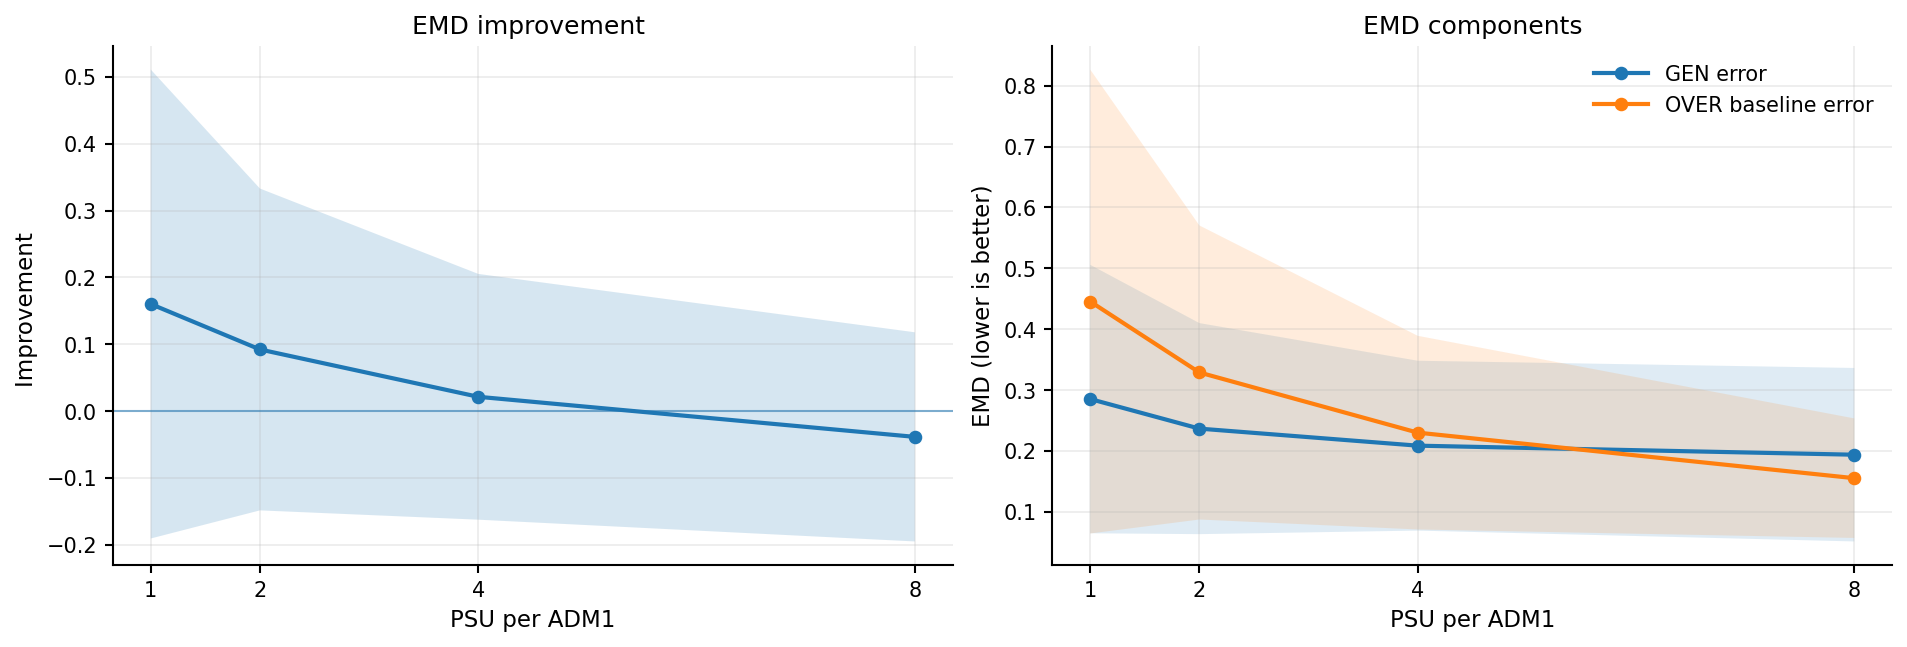

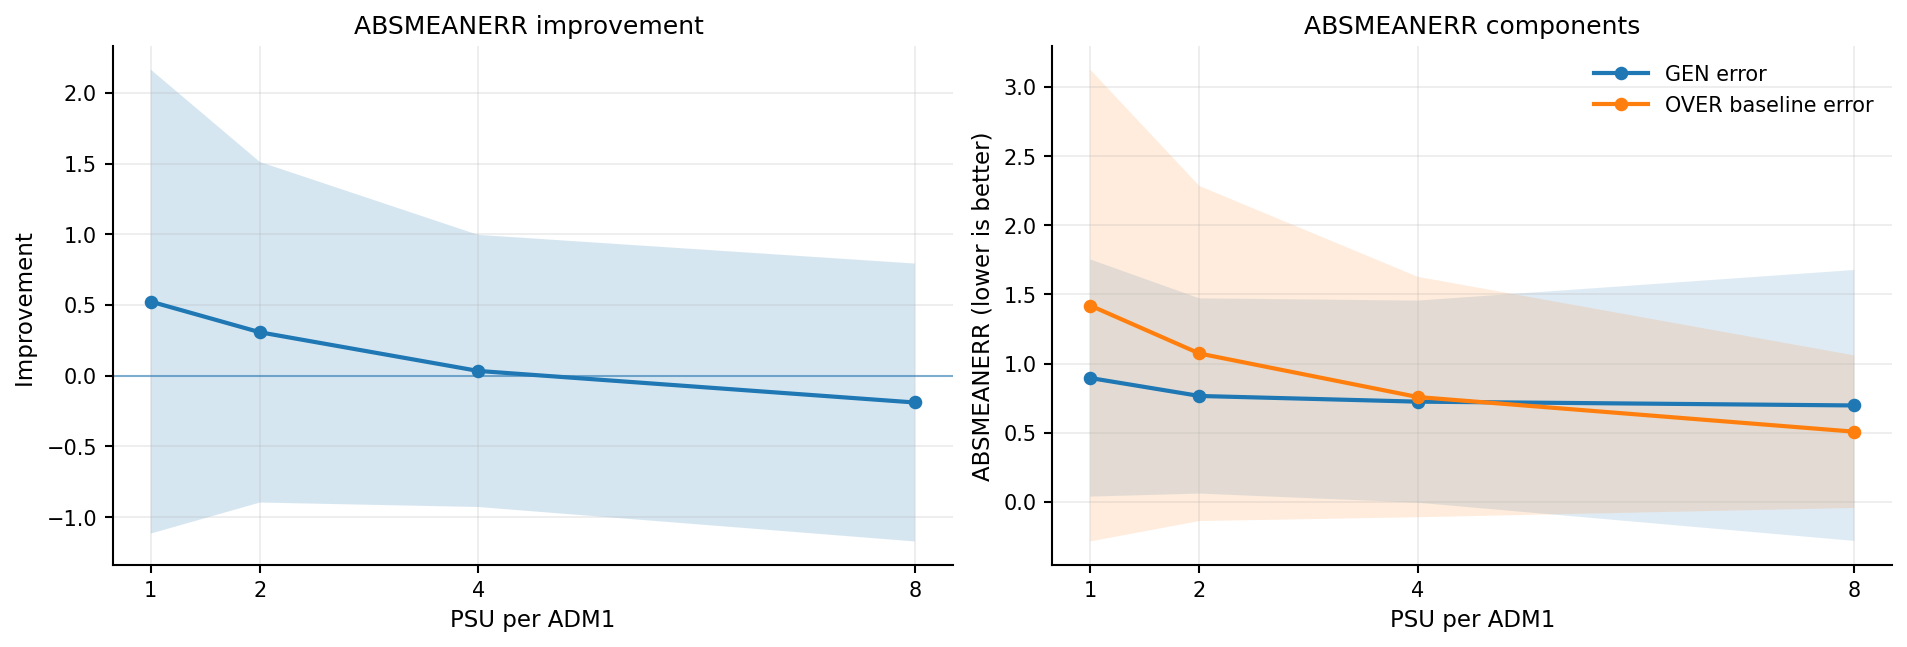

In [9]:
band_kind = sum_over["band_kind"].dropna().iloc[0] if sum_over["band_kind"].notna().any() else "se"

# Recommended: improvement band from row-level differences (accounts for correlation)
fig1 = plot_over_metric(sum_over, metric="emd", band_kind=band_kind, impr_band="rowdiff")
plt.show()

fig2 = plot_over_metric(sum_over, metric="absmeanerr", band_kind=band_kind, impr_band="rowdiff")
plt.show()

# Optional save:
# fig1.savefig("over_baseline_emd_ordinal.pdf", bbox_inches="tight")
# fig2.savefig("over_baseline_absmeanerr_ordinal.pdf", bbox_inches="tight")

In [10]:
# --- Cell 1: build NAT-only improvements + summary (both metrics)

import numpy as np
import pandas as pd

MAX_POS = 4
BAND = "sd"  # "se", "sd", or "ci95"

def _clean_np(a):
    a = np.asarray(a, dtype=float)
    return a[np.isfinite(a)]

def _sd(a):
    a = _clean_np(a)
    if a.size <= 1:
        return np.nan
    return a.std(ddof=1)

def _se(a):
    a = _clean_np(a)
    if a.size <= 1:
        return np.nan
    return a.std(ddof=1) / np.sqrt(a.size)

# Row-level improvements for NAT baseline (baseline - gen)
all_df["imp_emd_nat"] = all_df["emd_nat"] - all_df["emd_gen"]
all_df["imp_absmeanerr_nat"] = all_df["absmeanerr_nat"] - all_df["absmeanerr_gen"]

def summarize_nat(all_df: pd.DataFrame, band=BAND) -> pd.DataFrame:
    out_rows = []
    for pos, d in all_df.groupby("pos"):
        # components
        emd_g = d["emd_gen"].to_numpy()
        emd_b = d["emd_nat"].to_numpy()
        ame_g = d["absmeanerr_gen"].to_numpy()
        ame_b = d["absmeanerr_nat"].to_numpy()

        # improvements as row-level diffs (recommended; captures correlation)
        emd_imp = d["imp_emd_nat"].to_numpy()
        ame_imp = d["imp_absmeanerr_nat"].to_numpy()

        row = {
            "pos": pos,
            "n_emd_imp": int(np.isfinite(emd_imp).sum()),
            "n_ame_imp": int(np.isfinite(ame_imp).sum()),

            "emd_gen_mean": np.nanmean(emd_g),
            "emd_nat_mean": np.nanmean(emd_b),
            "emd_imp_mean": np.nanmean(emd_imp),

            "absmeanerr_gen_mean": np.nanmean(ame_g),
            "absmeanerr_nat_mean": np.nanmean(ame_b),
            "absmeanerr_imp_mean": np.nanmean(ame_imp),

            # component variability
            "emd_gen_sd": _sd(emd_g),
            "emd_nat_sd": _sd(emd_b),
            "absmeanerr_gen_sd": _sd(ame_g),
            "absmeanerr_nat_sd": _sd(ame_b),

            "emd_gen_se": _se(emd_g),
            "emd_nat_se": _se(emd_b),
            "absmeanerr_gen_se": _se(ame_g),
            "absmeanerr_nat_se": _se(ame_b),

            # improvement variability via row-level diffs
            "emd_imp_sd": _sd(emd_imp),
            "emd_imp_se": _se(emd_imp),
            "absmeanerr_imp_sd": _sd(ame_imp),
            "absmeanerr_imp_se": _se(ame_imp),
        }
        out_rows.append(row)

    sum_nat = pd.DataFrame(out_rows).sort_values("pos")

    # Reindex to preserve gaps for missing ordinal positions
    x = np.arange(1, MAX_POS + 1)
    sum_nat = (sum_nat.set_index("pos")
                      .reindex(x)
                      .reset_index()
                      .rename(columns={"index": "pos"}))

    # Optional: propagated SE assuming independence between baseline & gen means
    sum_nat["emd_imp_se_prop_indep"] = np.sqrt(sum_nat["emd_nat_se"]**2 + sum_nat["emd_gen_se"]**2)
    sum_nat["absmeanerr_imp_se_prop_indep"] = np.sqrt(sum_nat["absmeanerr_nat_se"]**2 + sum_nat["absmeanerr_gen_se"]**2)

    sum_nat["band_kind"] = band
    return sum_nat

sum_nat = summarize_nat(all_df, band=BAND)
sum_nat

,pos,n_emd_imp,n_ame_imp,emd_gen_mean,emd_nat_mean,emd_imp_mean,absmeanerr_gen_mean,absmeanerr_nat_mean,absmeanerr_imp_mean,emd_gen_sd,...,emd_nat_se,absmeanerr_gen_se,absmeanerr_nat_se,emd_imp_sd,emd_imp_se,absmeanerr_imp_sd,absmeanerr_imp_se,emd_imp_se_prop_indep,absmeanerr_imp_se_prop_indep,band_kind
0,1,3575,3575,0.285344,0.293208,0.007863,0.895655,0.933536,0.037881,0.220491,...,0.003857,0.014344,0.012062,0.212415,0.003553,0.836869,0.013996,0.005336,0.018741,sd
1,2,3575,3575,0.236763,0.262265,0.025502,0.765760,0.865917,0.100157,0.173346,...,0.003357,0.011804,0.010537,0.185683,0.003106,0.748092,0.012512,0.004436,0.015823,sd
2,3,3575,3575,0.208768,0.249794,0.041025,0.724627,0.849304,0.124677,0.139502,...,0.003039,0.012223,0.010304,0.170056,0.002844,0.747300,0.012498,0.003831,0.015987,sd
3,4,3575,3575,0.193909,0.244261,0.050352,0.697181,0.830787,0.133606,0.142481,...,0.002964,0.016381,0.009971,0.168709,0.002822,1.017273,0.017014,0.003804,0.019177,sd


In [11]:
# --- Cell 2: plotting helper (NAT baseline, 1×2 layout per metric) — x-axis at 1,2,4,8 (PSU per ADM1)

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np

mpl.rcParams.update({
    "figure.dpi": 150,
    "savefig.dpi": 300,
    "font.size": 11,
    "axes.titlesize": 12,
    "axes.labelsize": 11,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "legend.fontsize": 10,
    "axes.linewidth": 1.0,
    "lines.linewidth": 2.0,
    "lines.markersize": 5.5,
    "grid.linewidth": 0.8,
    "grid.alpha": 0.25,
})

def despine(ax):
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

def get_band(sum_df, col_base, kind):
    # col_base like "emd_gen" / "emd_nat" / "emd_imp"
    if kind == "sd":
        return sum_df[f"{col_base}_sd"].to_numpy()
    if kind == "ci95":
        return 1.96 * sum_df[f"{col_base}_se"].to_numpy()
    return sum_df[f"{col_base}_se"].to_numpy()

def plot_nat_metric(
    sum_nat,
    metric="emd",
    band_kind="se",
    impr_band="rowdiff",
    x_vals=(1, 2, 4, 8),
    x_label="PSU per ADM1",
):
    """
    NAT baseline, 1×2 layout per metric:
      - left: improvement (NAT − GEN)
      - right: components (GEN error, NAT baseline error)

    metric: "emd" or "absmeanerr"
    band_kind: "se", "sd", "ci95"
    impr_band:
      - "rowdiff" (uses metric_imp_{se/sd} computed from row-level diffs)
      - "prop_indep" (uses metric_imp_se_prop_indep; assumes independence of means)
    x_vals: actual x coordinates to plot at (default 1,2,4,8)
    """
    x = np.asarray(x_vals, dtype=float)

    fig, (ax0, ax1) = plt.subplots(
        1, 2, figsize=(12.6, 4.2), constrained_layout=True, sharex=True
    )

    # ----- Improvement
    y = sum_nat[f"{metric}_imp_mean"].to_numpy()

    if impr_band == "prop_indep":
        se_imp = sum_nat[f"{metric}_imp_se_prop_indep"].to_numpy()
        if band_kind == "ci95":
            b = 1.96 * se_imp
        else:
            b = se_imp  # SD doesn't apply cleanly here; fallback to SE
    else:
        b = get_band(sum_nat, f"{metric}_imp", band_kind)

    ax0.plot(x, y, marker="o")
    ax0.fill_between(x, y - b, y + b, alpha=0.18, linewidth=0)
    ax0.axhline(0, linewidth=1.0, alpha=0.55)
    ax0.set_title(f"{metric.upper()} improvement (NAT − GEN)")
    ax0.set_ylabel("Improvement (baseline − GEN)")
    ax0.set_xlabel(x_label)
    ax0.grid(True)
    ax0.tick_params(direction="out", length=4, width=1)
    despine(ax0)

    # ----- Components
    yg = sum_nat[f"{metric}_gen_mean"].to_numpy()
    yb = sum_nat[f"{metric}_nat_mean"].to_numpy()
    bg = get_band(sum_nat, f"{metric}_gen", band_kind)
    bb = get_band(sum_nat, f"{metric}_nat", band_kind)

    ax1.plot(x, yg, marker="o", label="GEN error")
    ax1.fill_between(x, yg - bg, yg + bg, alpha=0.14, linewidth=0)
    ax1.plot(x, yb, marker="o", label="NAT baseline error")
    ax1.fill_between(x, yb - bb, yb + bb, alpha=0.14, linewidth=0)

    ax1.set_title(f"{metric.upper()} components")
    ax1.set_ylabel(f"{metric.upper()} (lower is better)")
    ax1.set_xlabel(x_label)
    ax1.grid(True)
    ax1.tick_params(direction="out", length=4, width=1)
    despine(ax1)
    ax1.legend(frameon=False, loc="best", handlelength=2.6)

    # ticks exactly at the x values (so spacing matches 1,2,4,8)
    for ax in (ax0, ax1):
        ax.set_xticks(x)
        ax.set_xticklabels([str(int(v)) if float(v).is_integer() else str(v) for v in x])

    return fig

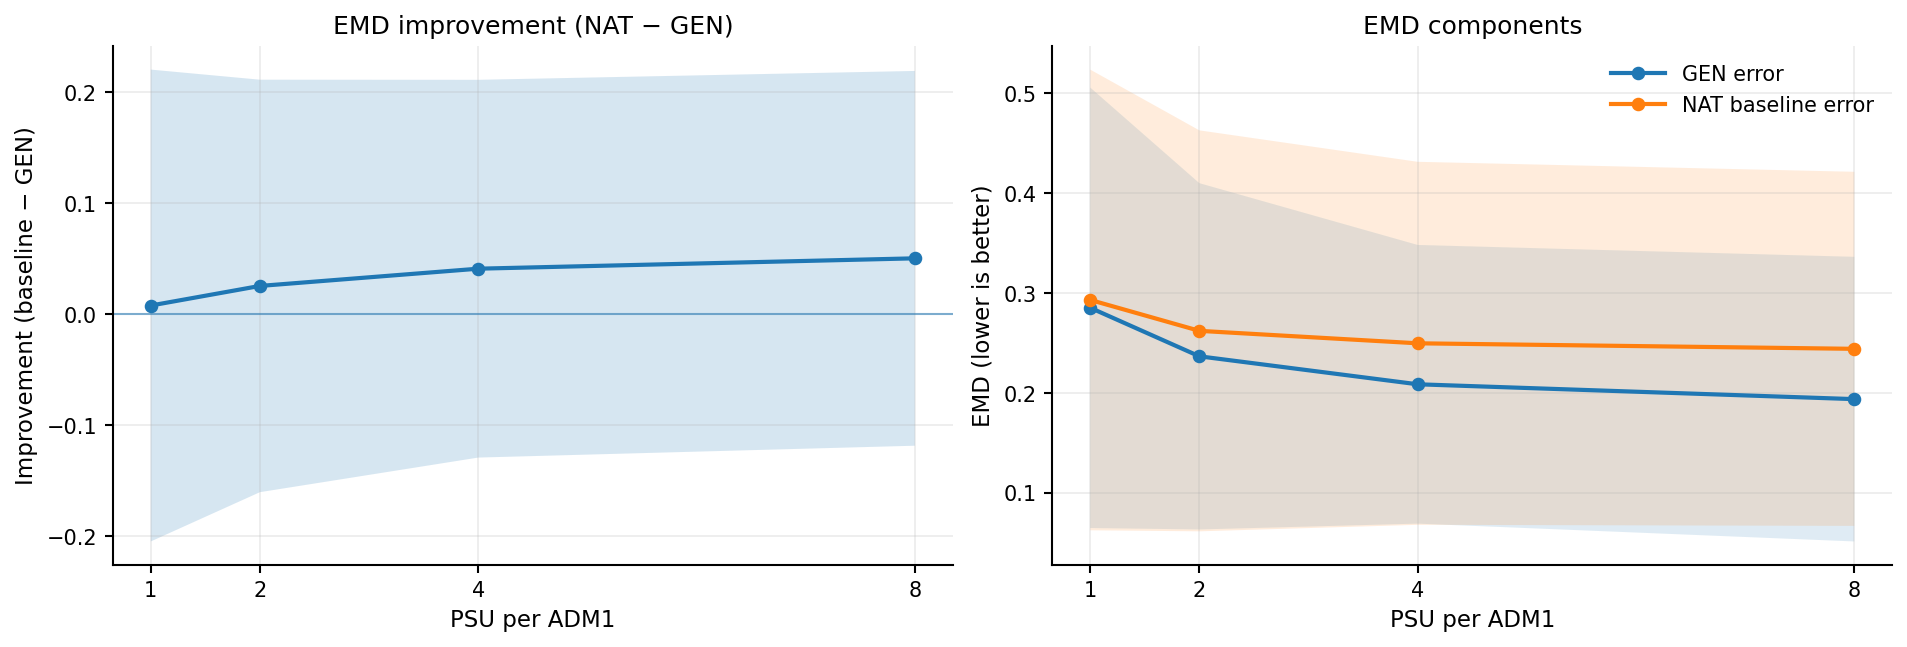

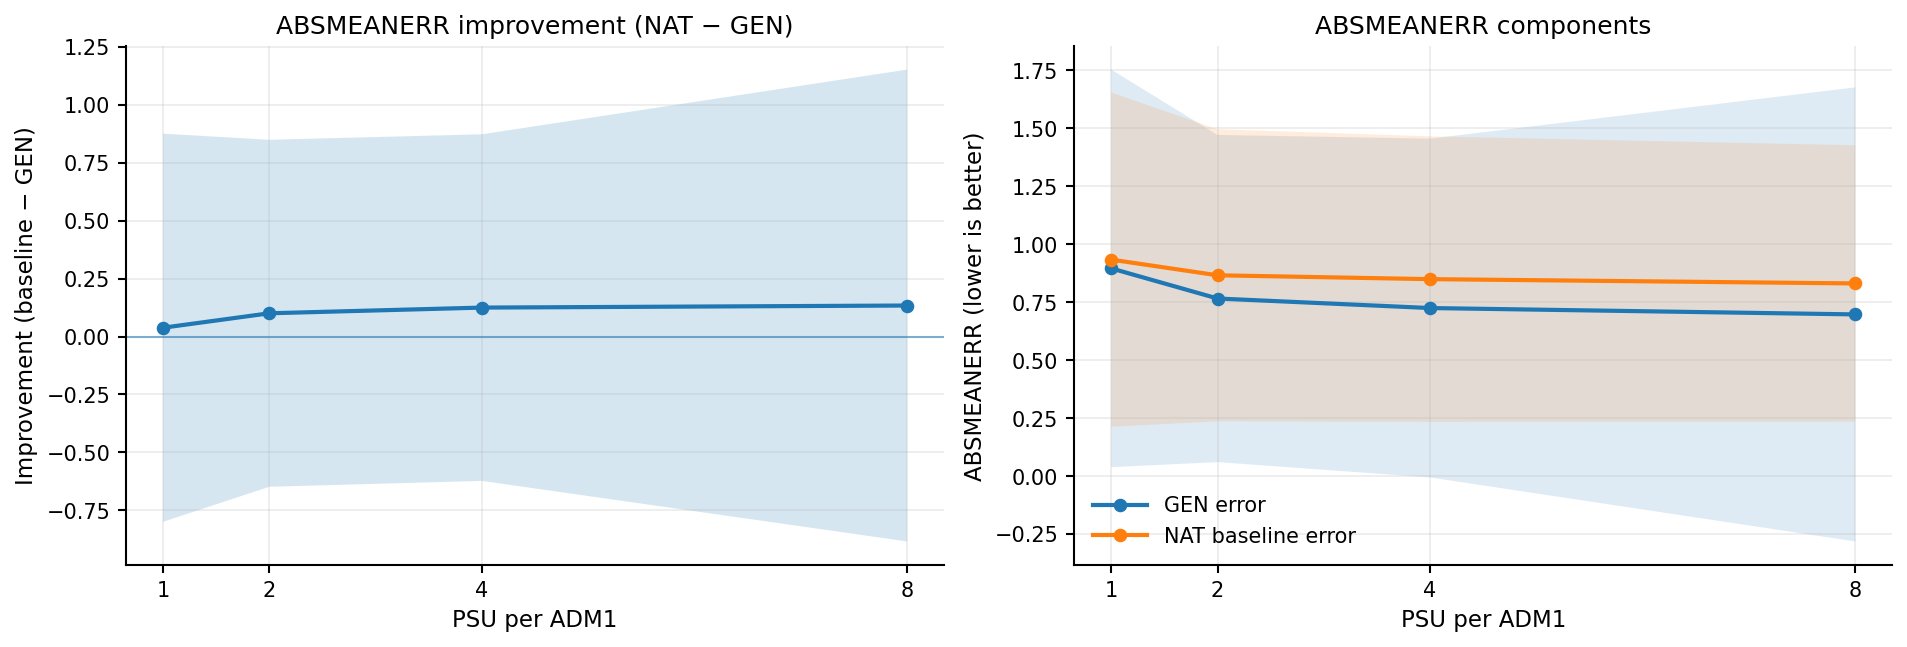

In [12]:
# --- Cell 3: make the two NAT figures (EMD and AbsMeanErr)

band_kind = sum_nat["band_kind"].dropna().iloc[0] if sum_nat["band_kind"].notna().any() else "se"

# Recommended: improvement band from row-level differences (captures correlation)
fig1 = plot_nat_metric(sum_nat, metric="emd", band_kind=band_kind, impr_band="rowdiff")
plt.show()

fig2 = plot_nat_metric(sum_nat, metric="absmeanerr", band_kind=band_kind, impr_band="rowdiff")
plt.show()

# Optional save:
# fig1.savefig("nat_baseline_emd_ordinal.pdf", bbox_inches="tight")
# fig2.savefig("nat_baseline_absmeanerr_ordinal.pdf", bbox_inches="tight")

In [13]:
import numpy as np
import pandas as pd

MAX_POS = 4
BAND = "se"  # "se", "sd", "ci95"

def _clean(a):
    a = np.asarray(a, dtype=float)
    return a[np.isfinite(a)]

def _sd(a):
    a = _clean(a)
    if a.size <= 1:
        return np.nan
    return a.std(ddof=1)

def _se(a):
    a = _clean(a)
    if a.size <= 1:
        return np.nan
    return a.std(ddof=1) / np.sqrt(a.size)

# Make sure row-level improvements exist (baseline - gen)
all_df["imp_emd_over"] = all_df["emd_over"] - all_df["emd_gen"]
all_df["imp_absmeanerr_over"] = all_df["absmeanerr_over"] - all_df["absmeanerr_gen"]
all_df["imp_emd_nat"] = all_df["emd_nat"] - all_df["emd_gen"]
all_df["imp_absmeanerr_nat"] = all_df["absmeanerr_nat"] - all_df["absmeanerr_gen"]

def summarize_baseline_between_datasets(all_df: pd.DataFrame, baseline: str, band=BAND) -> pd.DataFrame:
    """
    baseline: "over" or "nat"
    Produces a summary where variability bands reflect BETWEEN-dataset spread
    (dataset here is {country}_{dataset}).
    """
    if baseline not in {"over", "nat"}:
        raise ValueError("baseline must be 'over' or 'nat'")

    bcol_emd = f"emd_{baseline}"
    bcol_ame = f"absmeanerr_{baseline}"

    # --- Stage 1: dataset-level means at each pos
    # Each dataset contributes one number per pos (if present)
    ds = (
        all_df.groupby(["dataset", "pos"], as_index=False)
              .agg(
                  emd_gen_mean=("emd_gen", "mean"),
                  emd_base_mean=(bcol_emd, "mean"),
                  emd_imp_mean=(f"imp_emd_{baseline}", "mean"),

                  absmeanerr_gen_mean=("absmeanerr_gen", "mean"),
                  absmeanerr_base_mean=(bcol_ame, "mean"),
                  absmeanerr_imp_mean=(f"imp_absmeanerr_{baseline}", "mean"),
              )
    )

    # --- Stage 2: aggregate across datasets at each pos
    out_rows = []
    for pos, d in ds.groupby("pos"):
        row = {"pos": pos, "n_datasets": d["dataset"].nunique()}

        # components + improvement: mean across datasets
        for key in ["emd_gen_mean", "emd_base_mean", "emd_imp_mean",
                    "absmeanerr_gen_mean", "absmeanerr_base_mean", "absmeanerr_imp_mean"]:
            vals = d[key].to_numpy()
            row[key] = np.nanmean(vals)
            row[key.replace("_mean", "_sd")] = _sd(vals)
            row[key.replace("_mean", "_se")] = _se(vals)

        out_rows.append(row)

    sum_df = pd.DataFrame(out_rows).sort_values("pos")

    # Reindex to keep missing ordinal positions as gaps
    x = np.arange(1, MAX_POS + 1)
    sum_df = (sum_df.set_index("pos")
                    .reindex(x)
                    .reset_index()
                    .rename(columns={"index": "pos"}))

    # Rename "base" back to baseline-specific column names expected by plot helpers
    # plot_over_metric expects: emd_over_mean / absmeanerr_over_mean
    # plot_nat_metric expects: emd_nat_mean / absmeanerr_nat_mean
    sum_df = sum_df.rename(columns={
        "emd_base_mean": f"emd_{baseline}_mean",
        "emd_base_sd":   f"emd_{baseline}_sd",
        "emd_base_se":   f"emd_{baseline}_se",

        "absmeanerr_base_mean": f"absmeanerr_{baseline}_mean",
        "absmeanerr_base_sd":   f"absmeanerr_{baseline}_sd",
        "absmeanerr_base_se":   f"absmeanerr_{baseline}_se",
    })

    # Keep same names for gen + imp (already match the helpers)
    sum_df["band_kind"] = band

    return sum_df, ds

# Build OVER and NAT summaries with between-dataset variability
sum_over_between, ds_over = summarize_baseline_between_datasets(all_df, baseline="over", band=BAND)
sum_nat_between, ds_nat = summarize_baseline_between_datasets(all_df, baseline="nat", band=BAND)

sum_over_between.head(), sum_nat_between.head()

(   pos  n_datasets  emd_gen_mean  emd_gen_sd  emd_gen_se  emd_over_mean  \
 0    1           8      0.287545    0.084163    0.029756       0.456691   
 1    2           8      0.230598    0.059491    0.021033       0.335525   
 2    3           8      0.199674    0.034311    0.012131       0.233077   
 3    4           8      0.193392    0.060192    0.021281       0.157980   
 
    emd_over_sd  emd_over_se  emd_imp_mean  emd_imp_sd  ...  \
 0     0.093899     0.033198      0.169146    0.043782  ...   
 1     0.064482     0.022798      0.104927    0.032000  ...   
 2     0.042560     0.015047      0.033403    0.022568  ...   
 3     0.026302     0.009299     -0.035412    0.066319  ...   
 
    absmeanerr_gen_mean  absmeanerr_gen_sd  absmeanerr_gen_se  \
 0             1.035106           0.337070           0.119172   
 1             0.845864           0.248898           0.087999   
 2             0.829404           0.311057           0.109975   
 3             0.876278           0.60802

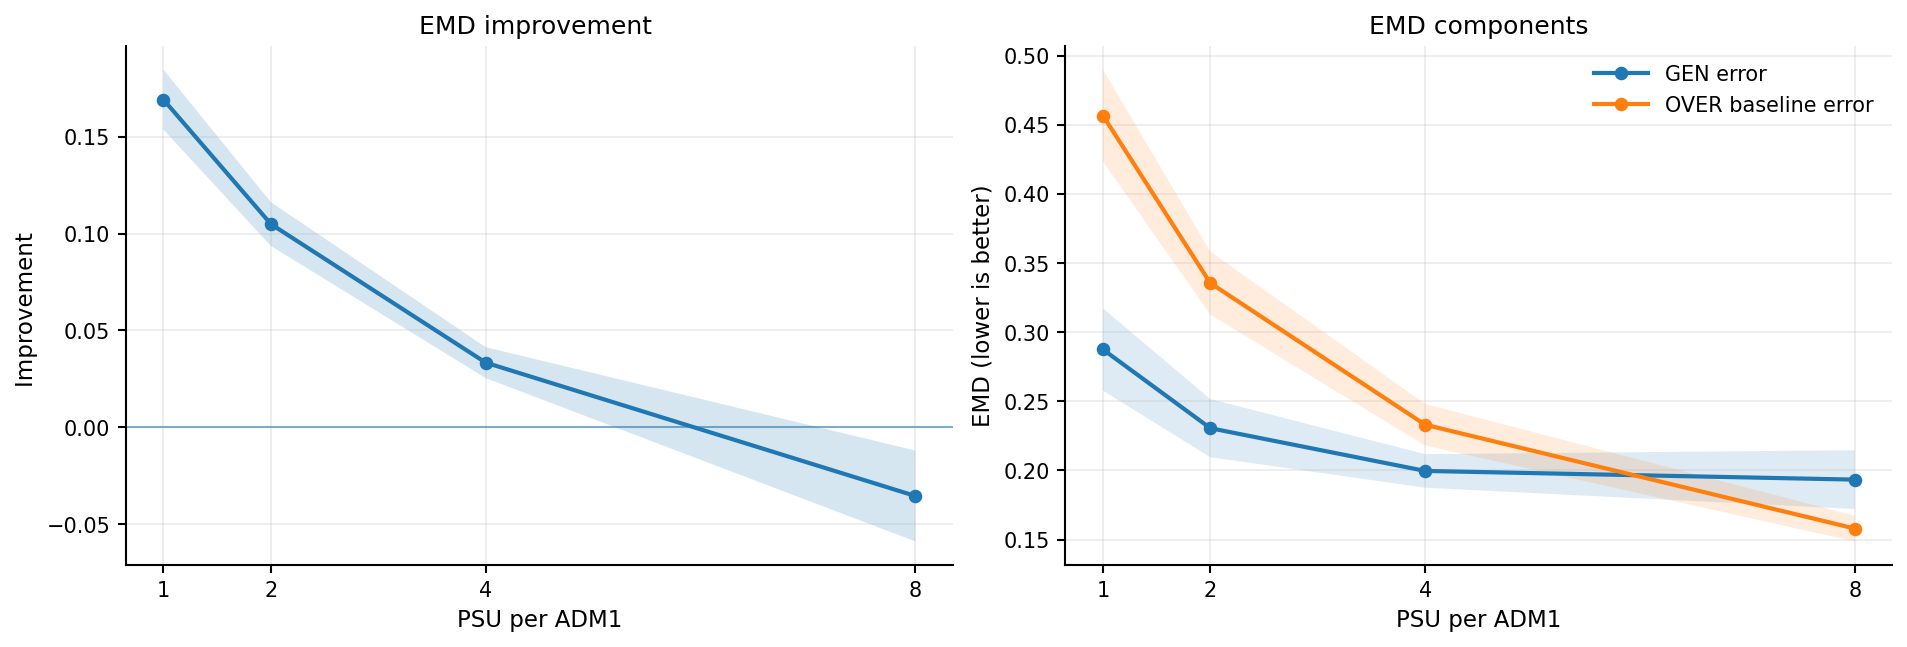

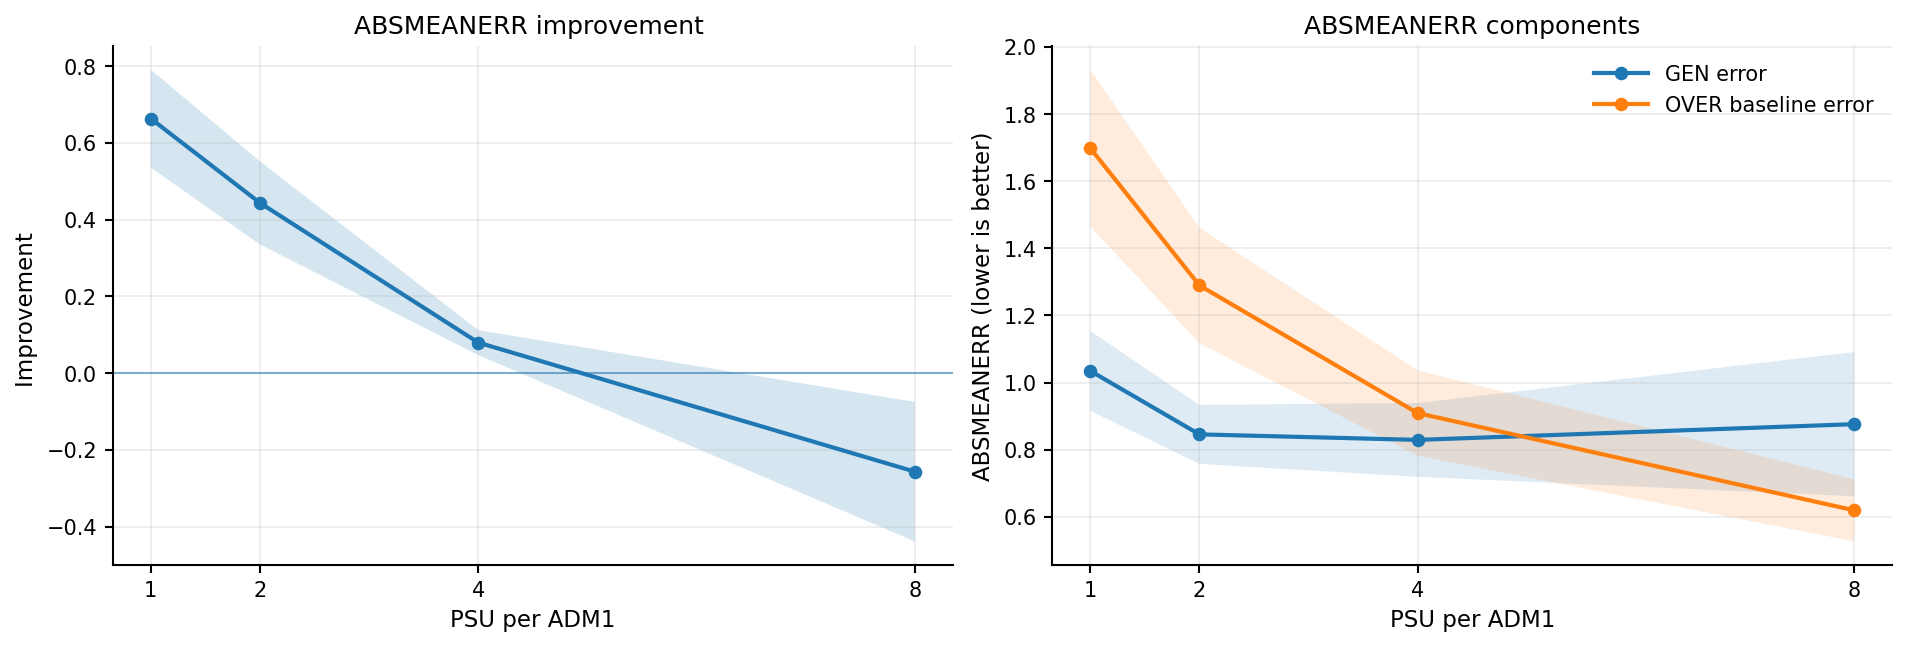

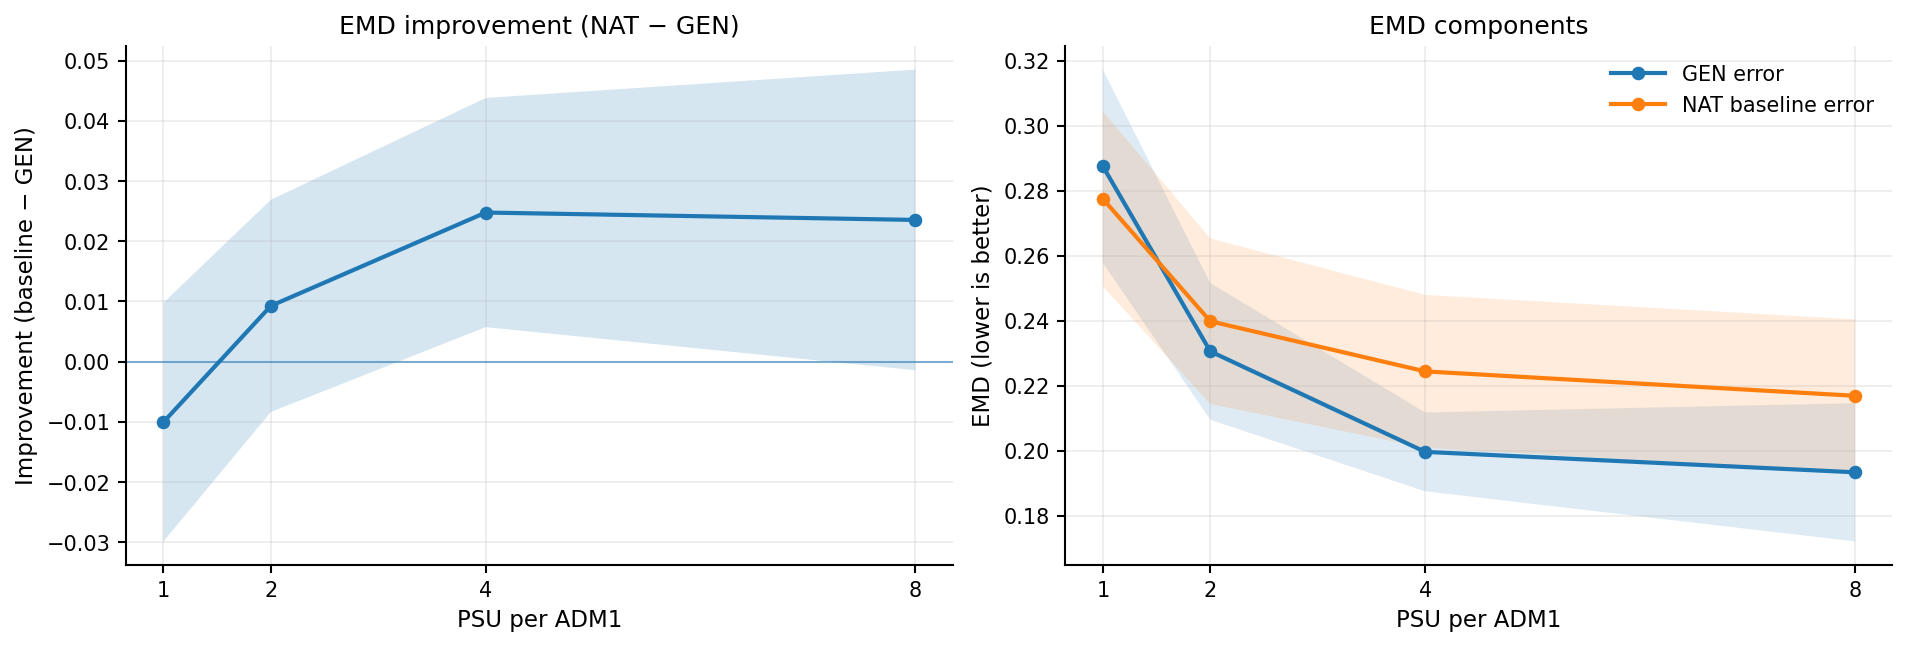

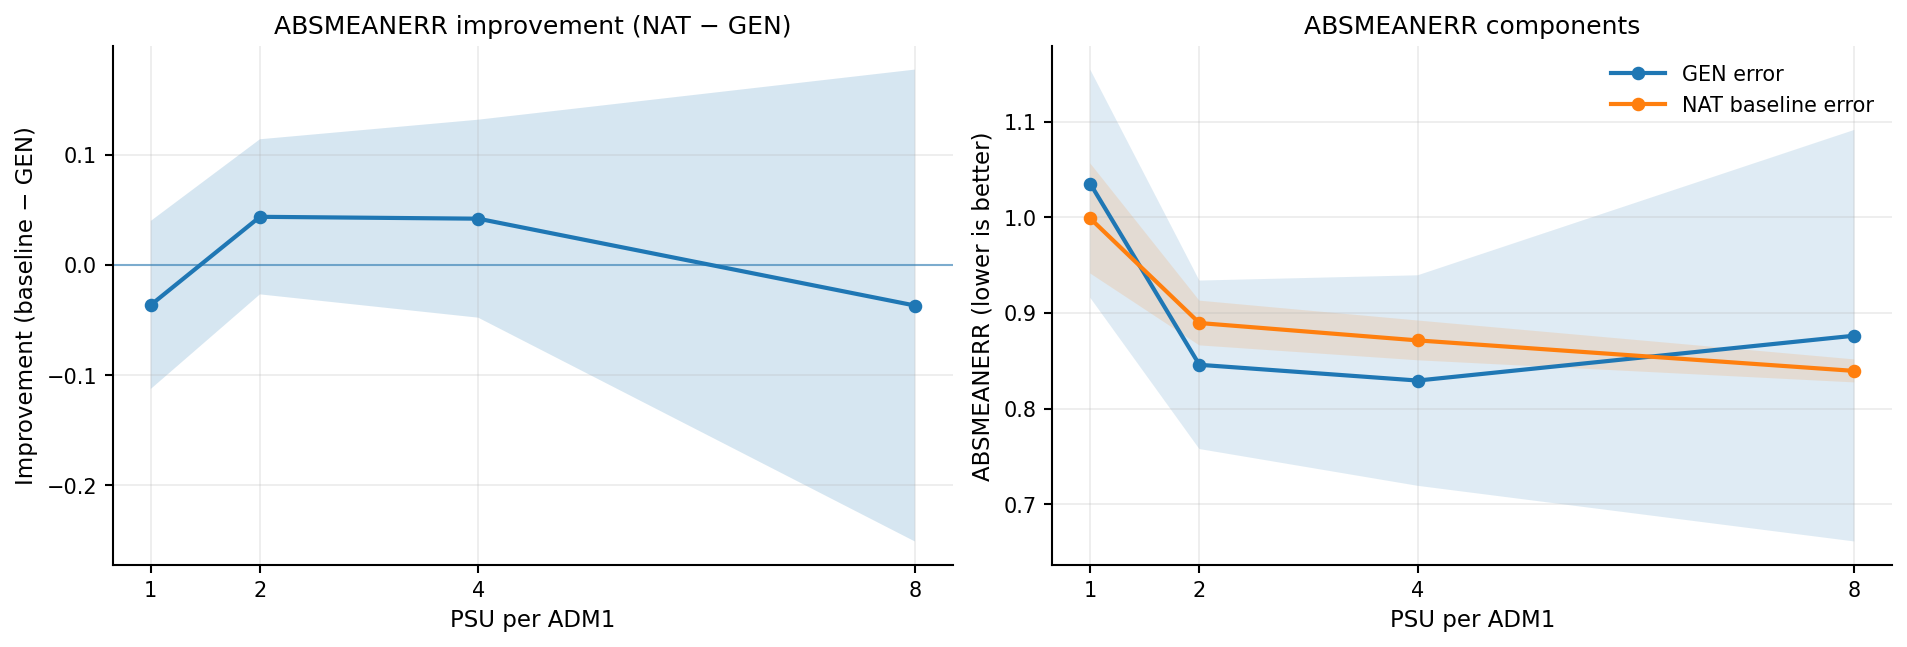

In [14]:
# OVER baseline (between-dataset bands)
fig = plot_over_metric(sum_over_between, metric="emd", band_kind=BAND, impr_band="rowdiff", x_vals=(1,2,4,8))
plt.show()

fig = plot_over_metric(sum_over_between, metric="absmeanerr", band_kind=BAND, impr_band="rowdiff", x_vals=(1,2,4,8))
plt.show()

# NAT baseline (between-dataset bands)
fig = plot_nat_metric(sum_nat_between, metric="emd", band_kind=BAND, impr_band="rowdiff", x_vals=(1,2,4,8))
plt.show()

fig = plot_nat_metric(sum_nat_between, metric="absmeanerr", band_kind=BAND, impr_band="rowdiff", x_vals=(1,2,4,8))
plt.show()